# 04 · Confiabilidad de las métricas

Fase CRISP-DM **Evaluation**. El DQS mide **propiedades del dato** (nulos,
rangos, unicidad). La confiabilidad mide **la confianza en las métricas**:
¿ese 92.07 es un hecho o el resultado de decisiones mías?, ¿cuánta
incertidumbre tiene?, ¿qué parte de la validación es tautológica?

> **No se calcula un "índice de confiabilidad".** Un número único repetiría
> el error que hace malinterpretable el DQS. En su lugar se produce una
> **tabla de afirmaciones verificables**, cada una con su veredicto, su
> evidencia medida y su límite conocido.

Todo lo que hay aquí se **calcula** con `src/quality/reliability.py`: no hay
ni un solo número escrito a mano.

Requisito previo: `python scripts/run_pipeline.py`

## 4.1 · Qué ejes se evalúan

| Eje | La pregunta incómoda que responde |
|---|---|
| Reproducibilidad | ¿Da el pipeline el mismo resultado si se ejecuta otra vez? |
| Trazabilidad | ¿Se puede trazar el origen de cada número publicado? |
| Robustez del DQS | ¿El 92.07 depende de los pesos que elegí yo? |
| Incertidumbre | ¿Cuánta incertidumbre tiene el DQS que se publica? |
| **Circularidad** | ¿La validación contra catálogos es real o tautológica? |
| Cobertura del universo | ¿El dataset representa todos los siniestros? |
| Integridad referencial | ¿La dimensión `integrity` aporta información? |
| Consistencia cruzada | ¿ONSV y cinemómetros coinciden en su geografía? |
| Imputación | ¿Qué métricas son mediciones y cuáles estimaciones? |
| Deriva temporal | ¿La calidad se mantiene en el tiempo? |

Los veredictos posibles son `alta`, `media`, `baja` y `no_verificable`.
`no_verificable` no es un fallo: es una frontera honesta, el punto donde
los datos disponibles dejan de poder responder.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
sys.path.insert(0, str(ROOT))

from src.utils.configloader import expand_path, load_catalogs, load_settings, load_sources

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 160)

SETTINGS = load_settings()
import base64 as _b64

from IPython.display import Image as _Image, display

from src.quality import figures as F
from src.quality import reliability as R


def _show(png_path):
    """Incrusta un PNG en el notebook (Agg no permite plt.show())."""
    p = Path(png_path)
    if not p.exists():
        print('Falta', p, '- ejecuta: python scripts/graficos_etl.py')
        return
    display(_Image(data=_b64.b64decode(_b64.b64encode(p.read_bytes()))))

def _silver(ds):
    v = SETTINGS['datasets'][ds]['version']
    p = ROOT / 'data' / 'silver' / f'{ds}_silver_{v}.parquet'
    return pd.read_parquet(p) if p.exists() else None


frames = {ds: _silver(ds) for ds in SETTINGS['datasets']}
frames = {k: v for k, v in frames.items() if v is not None}
print('Silver disponible:', {k: v.shape for k, v in frames.items()})
if not frames:
    print('Sin Silver: ejecuta primero python scripts/run_pipeline.py')

Silver disponible: {'onsv': (9106, 33), 'cinemometros': (160018, 13)}


In [2]:
assess = {}
for ds, df in frames.items():
    otros = {k: v for k, v in frames.items() if k != ds}
    assess[ds] = R.assess(ds, df, settings=SETTINGS, other_frames=otros)
    print(f"{ds:14} DQS {assess[ds]['dqs']['dqs']:6.2f}   "
          f"{assess[ds]['resumen_veredictos']}")

onsv           DQS  92.07   {'alta': 4, 'media': 2, 'baja': 2, 'no_verificable': 2}


cinemometros   DQS  92.00   {'alta': 4, 'media': 1, 'baja': 2, 'no_verificable': 2}


## 4.2 · La tabla de afirmaciones

Cada fila es una afirmación verificable: la pregunta, el veredicto, la evidencia
medida y el límite que la acota. El veredicto no es un número del eje: es un
dictamen sobre si ese eje se puede sostener.

In [3]:
def _tabla_claims(res):
    filas = []
    for c in res['claims']:
        ev = c['evidence']
        # El evidence puede traer dicts/listas anidados; para la tabla se
        # aplana a los escalares, que son los valores citables.
        simple = {k: v for k, v in ev.items() if not isinstance(v, (dict, list))}
        filas.append({
            'id': c['id'],
            'eje': c['axis'],
            'veredicto': c['verdict'],
            'evidencia': ', '.join(f'{k}={v}' for k, v in simple.items()),
        })
    return pd.DataFrame(filas)


for ds, res in assess.items():
    print(f"\n=== {ds}: {res['resumen_veredictos']} ===")
    display(_tabla_claims(res))


=== onsv: {'alta': 4, 'media': 2, 'baja': 2, 'no_verificable': 2} ===


,id,eje,veredicto,evidencia
0,A1,Reproducibilidad,alta,"corridas=29, huellas_distintas=3, huella_vigen..."
1,A2,Trazabilidad,alta,"manifest_por_corrida=True, lineage_duckdb=sour..."
2,A2b,Robustez del DQS,media,"dqs_config=92.07, p05=87.77, p95=96.19, spread..."
3,A3,Incertidumbre,alta,"n_remuestreos=300, ci=0.95, dqs_punto=92.07, a..."
4,A4,Circularidad,baja,"catalogos_analizados=6, catalogos_circulares=6"
5,A5,Cobertura del universo,no_verificable,"frac_anio_modal_pct=27.23, dias_unicos=1727"
6,A6,Integridad referencial,no_verificable,"valor_integridad=100.0, fk_configuradas=0"
7,A7,Consistencia cruzada,baja,
8,A8,Imputación,media,
9,A9,Deriva temporal,alta,"corridas_totales=64, cambio_entre_huellas=1.17"



=== cinemometros: {'alta': 4, 'media': 1, 'baja': 2, 'no_verificable': 2} ===


,id,eje,veredicto,evidencia
0,A1,Reproducibilidad,alta,"corridas=35, huellas_distintas=3, huella_vigen..."
1,A2,Trazabilidad,alta,"manifest_por_corrida=True, lineage_duckdb=sour..."
2,A2b,Robustez del DQS,media,"dqs_config=92.0, p05=87.67, p95=96.16, spread_..."
3,A3,Incertidumbre,alta,"n_remuestreos=300, ci=0.95, dqs_punto=92.0, am..."
4,A4,Circularidad,baja,"catalogos_analizados=1, catalogos_circulares=1"
5,A5,Cobertura del universo,no_verificable,"frac_anio_modal_pct=54.57, dias_unicos=459"
6,A6,Integridad referencial,no_verificable,"valor_integridad=100.0, fk_configuradas=0"
7,A7,Consistencia cruzada,baja,
8,A9,Deriva temporal,alta,"corridas_totales=64, cambio_entre_huellas=0.53"


## 4.3 · Robustez del DQS: ¿de quién es el 92.07?

La pregunta que casi nunca se hace a un indicador ponderado: *el peso 0.22 de
completitud lo elegiste tú, así que el 92.07 también es tuyo*. La respuesta se
recalcula con 300 perturbaciones de los pesos y con cuatro escenarios declarados
en `config/quality/reliability_rules.yaml`.

In [4]:
for ds, res in assess.items():
    ws = res['detalle']['weight_sensitivity']
    print(f"\n=== {ds} ===")
    print(f"  spread p05-p95 = {ws['spread_p05_p95']:.2f} puntos "
          f"({ws['n_samples']} perturbaciones)")
    print(f"  p05={ws['distribucion']['p05']:.2f}  p95={ws['distribucion']['p95']:.2f}")
    for e in ws['scenarios']:
        print(f"  {e['name']:22} {e['dqs']:6.2f}  ({e['delta_vs_config']:+.2f})")


=== onsv ===
  spread p05-p95 = 8.43 puntos (300 perturbaciones)
  p05=87.77  p95=96.19
  uniforme                83.48  (-8.59)
  frescura_critica        70.26  (-21.81)
  integridad_critica      95.04  (+2.97)
  solo_contrato          100.00  (+7.93)

=== cinemometros ===
  spread p05-p95 = 8.50 puntos (300 perturbaciones)
  p05=87.67  p95=96.16
  uniforme                83.34  (-8.66)
  frescura_critica        70.00  (-22.00)
  integridad_critica      95.00  (+3.00)
  solo_contrato          100.00  (+8.00)


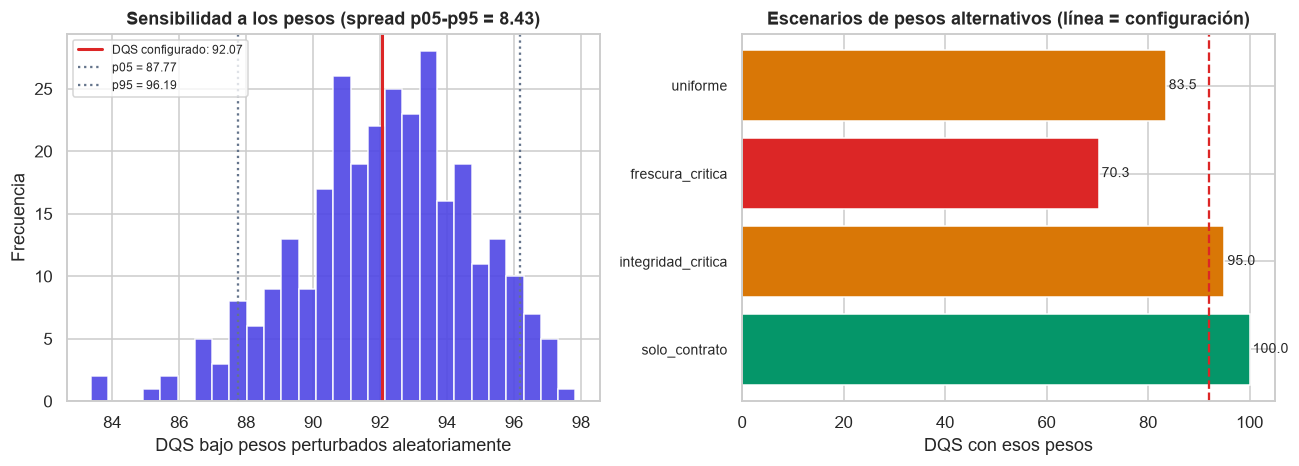

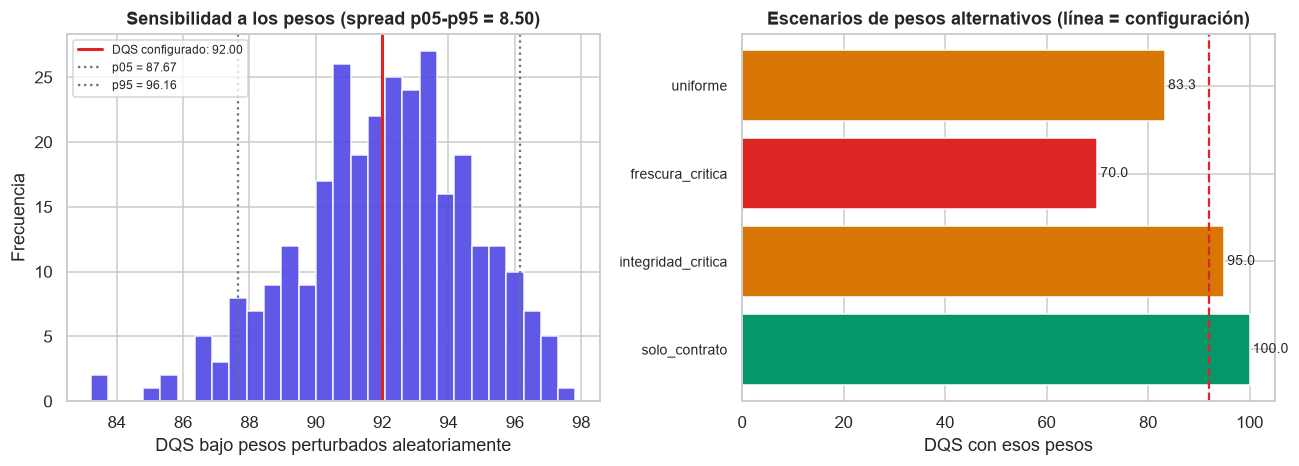

In [5]:
for ds, res in assess.items():
    ws = dict(res['detalle']['weight_sensitivity'])
    ws['distribucion_valores'] = res['detalle'].get('weight_sensitivity_distribucion', [])
    _show(F.plot_weight_sensitivity(ws, F.figures_dir(), ds))

## 4.4 · Incertidumbre: cuánto se movería con otra muestra

El DQS es una media de medias: sin este cálculo, `92.07` se lee como un número
exacto cuando en realidad es un estimador puntual. Bootstrap con reemplazo,
300 remuestreos, IC 95 %.

Ojo con `uniqueness` e `integrity`: se **fijan** al valor observado. Remuestrear
filas con reemplazo duplica las claves primarias y hundiría la unicidad por un
artefacto del remuestreo, no por el dataset (ver 4.12).

In [6]:
for ds, res in assess.items():
    boot = res['detalle']['bootstrap']
    print(f"\n=== {ds} ===")
    for k, v in boot.items():
        if isinstance(v, dict) and 'punto' in v:
            print(f"  {k:14} {v['punto']:7.2f}  IC [{v['ic_inf']:6.2f}, {v['ic_sup']:6.2f}]"
                  f"  amplitud {v['amplitud']:.2f}  centrado={v['centrado']}")
    print(f"  dimensiones fijadas: {boot['fix_dimensions']}")


=== onsv ===
  completeness    100.00  IC [100.00, 100.00]  amplitud 0.00  centrado=True
  validity        100.00  IC [100.00, 100.00]  amplitud 0.00  centrado=True
  uniqueness      100.00  IC [100.00, 100.00]  amplitud 0.00  centrado=True
  consistency     100.00  IC [100.00, 100.00]  amplitud 0.00  centrado=True
  integrity       100.00  IC [100.00, 100.00]  amplitud 0.00  centrado=True
  freshness         0.86  IC [  0.69,   1.08]  amplitud 0.39  centrado=True
  dqs              92.07  IC [ 92.06,  92.09]  amplitud 0.03  centrado=True
  dimensiones fijadas: ['integrity', 'uniqueness']

=== cinemometros ===
  completeness    100.00  IC [100.00, 100.00]  amplitud 0.00  centrado=True
  validity        100.00  IC [100.00, 100.00]  amplitud 0.00  centrado=True
  uniqueness      100.00  IC [100.00, 100.00]  amplitud 0.00  centrado=True
  consistency     100.00  IC [100.00, 100.00]  amplitud 0.00  centrado=True
  integrity       100.00  IC [100.00, 100.00]  amplitud 0.00  centrado=True
 

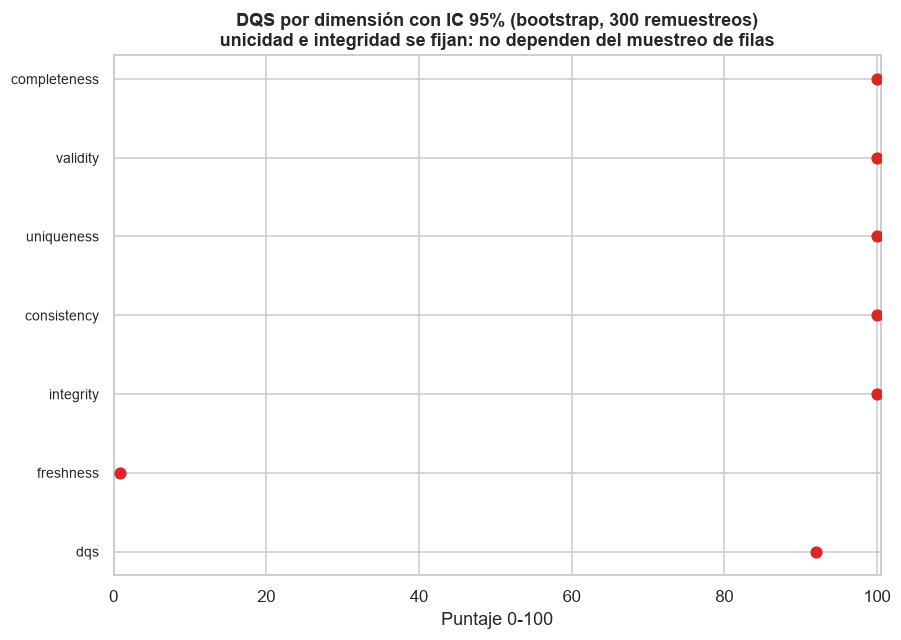

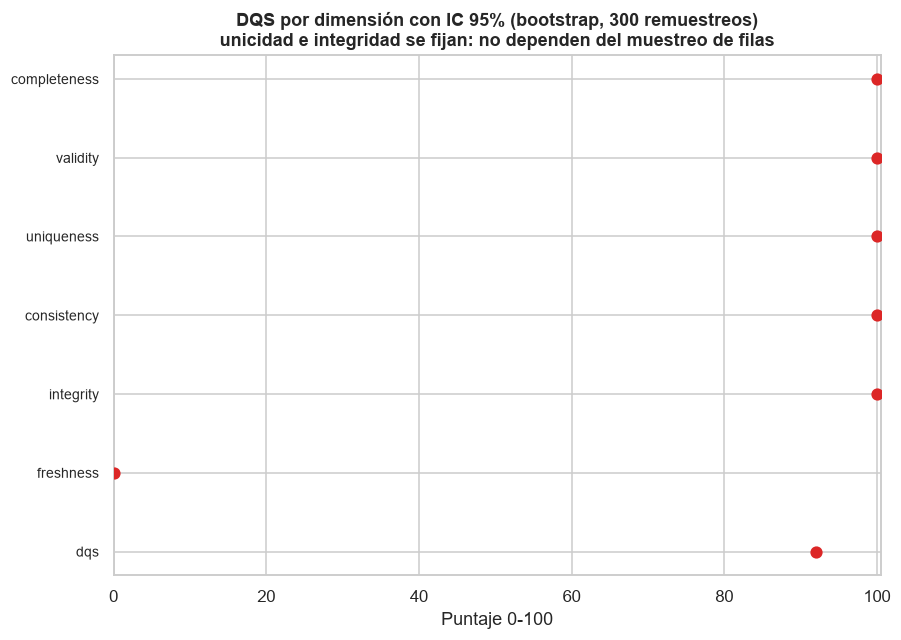

In [7]:
for ds, res in assess.items():
    _show(F.plot_bootstrap_ci(res['detalle']['bootstrap'], F.figures_dir(), ds))

## 4.5 · Circularidad: el límite más serio

La validación de este proyecto se hace contra `config/quality/catalogs/*.yaml`, y
esos catálogos se derivaron de los valores **observados en el propio dataset**.

Validar contra un catálogo hecho con esos mismos datos y obtener 100 % no
demuestra que los datos sean correctos: demuestra que son consistentes consigo
mismos. Un valor mal escrito en la fuente entra en el catálogo y se aprueba a sí
mismo. Por eso este eje se declara en vez de esconderlo, y por eso el veredicto
es `baja` y no `alta`.

**No es un defecto del código: es un límite de la información disponible.**
Solo se cerraría contrastando con una fuente externa (catálogo oficial de INEI,
maestro UBIGEO), que no está en este workspace.

In [8]:
for ds, res in assess.items():
    circ = res['detalle']['catalog_circularity']
    print(f"\n=== {ds}: {circ['catalogos_circulares']}/{circ['catalogos_analizados']}"
          f" catálogos circulares (umbral {circ['threshold_pct']}%) ===")
    for d in circ['detalle']:
        print(f"  {d['catalogo']:14} {d['pct_valores_derivados_del_dato']:6.2f}% derivado del dato")
        if d['valores_fuera_de_catalogo']:
            print(f"    fuera de catálogo: {d['valores_fuera_de_catalogo']}")


=== onsv: 6/6 catálogos circulares (umbral 80.0%) ===
  departamentos  100.00% derivado del dato
  clase          100.00% derivado del dato
  condicion_climatica 100.00% derivado del dato
  causa_factor_principal 100.00% derivado del dato
  red_vial       100.00% derivado del dato
  zona           100.00% derivado del dato

=== cinemometros: 1/1 catálogos circulares (umbral 80.0%) ===
  carreteras     100.00% derivado del dato


## 4.6 · Cobertura del universo: la incógnita más grande

El dataset puede tener **cero nulos** en todas sus columnas obligatorias y aun
así estar incompleto: eso mide nulos, no si la fuente publicó todos los
siniestros.

Sin el total oficial de ONSV/MTC, cualquier afirmación sobre «la siniestralidad
vial en el Perú» basada en este dataset es una afirmación sobre **el dataset**, no
sobre el país. Es el límite más relevante para quien use estos números.

In [9]:
for ds, res in assess.items():
    cov = res['detalle']['coverage']
    if not cov.get('disponible'):
        print(f"{ds}: sin columna de fecha configurada")
        continue
    anios = cov['anios']
    modal = max(anios, key=anios.get)
    print(f"\n=== {ds} (columna '{cov['columna']}') ===")
    print(f"  rango        : {cov['fecha_min']} -> {cov['fecha_max']}")
    print(f"  registros por año: {anios}")
    print(f"  años vacíos  : {cov['anios_vacios'] or 'ninguno'}")
    print(f"  año modal    : {modal} con {cov['frac_anio_modal_pct']:.2f}% de los registros")
    print(f"  fechas parseadas: {cov['n_fechas_parseadas']}  nulas: {cov['n_fechas_nulas']}")
    print(f"  días únicos  : {cov['dias_unicos']}")


=== onsv (columna 'fecha') ===
  rango        : 2021-01-01 -> 2025-12-30
  registros por año: {2021: 2392, 2022: 2480, 2023: 2001, 2024: 1555, 2025: 678}
  años vacíos  : ninguno
  año modal    : 2022 con 27.23% de los registros
  fechas parseadas: 9106  nulas: 0
  días únicos  : 1727

=== cinemometros (columna 'fecha_papeleta') ===
  rango        : 2019-10-31 -> 2021-10-03
  registros por año: {2019: 4867, 2020: 67833, 2021: 87318}
  años vacíos  : ninguno
  año modal    : 2021 con 54.57% de los registros
  fechas parseadas: 160018  nulas: 0
  días únicos  : 459


## 4.7 · Consistencia cruzada: ONSV contra cinemómetros

Dos fuentes independientes con dos geografías distintas. Sin un maestro UBIGEO
no hay forma de arbitrar cuál tiene razón, así que el pipeline **declara** la
divergencia en vez de corregirla a ciegas: inventar una equivalencia entre
departamentos y regiones sería un dato falso con apariencia de limpieza.

In [10]:
for ds, res in assess.items():
    cross = res['detalle']['cross_dataset']
    if not cross.get('enabled'):
        print('consistencia cruzada desactivada')
        continue
    print(f"\n=== {ds} ===")
    for c in cross['comparaciones']:
        if not c.get('disponible'):
            print(f"  {c.get('a')} vs {c.get('b')}: {c.get('motivo', 'no comparable')}")
            continue
        col_a = f"{c['a']}.{c['columnas'][0]}"
        col_b = f"{c['b']}.{c['columnas'][1]}"
        print(f"  {col_a} ({c['valores_a']} valores) vs {col_b} ({c['valores_b']} valores)")
        print(f"    coincidentes   : {c['valores_comunes']}  (Jaccard {c['jaccard']})")
        print(f"    solo en {c['a']}: {c['solo_en_a']}")
        print(f"    solo en {c['b']}: {c['solo_en_b']}")
    print(f"  veredicto: {cross['verdict']}")
    print(f"  nota     : {cross['nota']}")


=== onsv ===
  onsv.departamento (25 valores) vs cinemometros.region (10 valores)
    coincidentes   : 10  (Jaccard 0.4)
    solo en onsv: ['AMAZONAS', 'APURIMAC', 'AYACUCHO', 'CAJAMARCA', 'CALLAO', 'CUSCO', 'HUANCAVELICA', 'HUANUCO', 'LORETO', 'MADRE DE DIOS', 'PASCO', 'SAN MARTIN', 'TACNA', 'TUMBES', 'UCAYALI']
    solo en cinemometros: []
  veredicto: baja
  nota     : Sin maestro UBIGEO la divergencia se declara; no se corrige automáticamente.

=== cinemometros ===
  onsv.departamento (25 valores) vs cinemometros.region (10 valores)
    coincidentes   : 10  (Jaccard 0.4)
    solo en onsv: ['AMAZONAS', 'APURIMAC', 'AYACUCHO', 'CAJAMARCA', 'CALLAO', 'CUSCO', 'HUANCAVELICA', 'HUANUCO', 'LORETO', 'MADRE DE DIOS', 'PASCO', 'SAN MARTIN', 'TACNA', 'TUMBES', 'UCAYALI']
    solo en cinemometros: []
  veredicto: baja
  nota     : Sin maestro UBIGEO la divergencia se declara; no se corrige automáticamente.


## 4.8 · Una dimensión vacía y las estimaciones

Dos hallazgos que el número agregado esconde:

- `integrity` vale **100 siempre**, porque no hay claves foráneas configuradas
  entre datasets. No es buena señal: es una dimensión que no mide nada, y por eso
  tiene su propia afirmación con veredicto `no_verificable`.
- Las columnas **imputadas** convierten esas métricas en *estimaciones*, no en
  mediciones. Deben declararse siempre que se usen.

In [11]:
for ds, res in assess.items():
    integ = res['detalle']['integrity']
    imput = res['detalle']['imputation']
    print(f"\n=== {ds} ===")
    print(f"  integridad = {integ['valor']}  ->  {integ['verdict']}")
    print(f"    {integ['motivo']}")
    if imput.get('enabled') and imput.get('columnas_imputadas'):
        print(f"  imputadas: {imput['columnas_imputadas']}")
        print(f"    {imput['motivo']}")
    else:
        print('  sin imputaciones registradas en la config')


=== onsv ===
  integridad = 100.0  ->  no_verificable
    La dimensión integrity está fijada a 100 porque no hay claves foráneas entre datasets. No aporta información: no debe leerse como 'integridad perfecta'.
  imputadas: [{'columna': 'vehiculos_danados', 'estrategia': 'median', 'valor': None, 'nulos_restantes': 0, 'pct_revisado': 0.0, 'supera_umbral': False}, {'columna': 'condicion_climatica', 'estrategia': 'domain_rule', 'valor': 'DESCONOCIDO', 'nulos_restantes': 0, 'pct_revisado': 0.0, 'supera_umbral': False}]
    Las métricas de estas columnas son ESTIMACIONES, no mediciones. Debe declararse al usarlas.

=== cinemometros ===
  integridad = 100.0  ->  no_verificable
    La dimensión integrity está fijada a 100 porque no hay claves foráneas entre datasets. No aporta información: no debe leerse como 'integridad perfecta'.
  sin imputaciones registradas en la config


## 4.9 · Deriva por huella de medición, no por commit

Dos corridas solo son comparables si se hicieron con el **mismo método de
medición**. La opción obvia sería agrupar por `git_commit`, pero tras integrar el
ETL en el repositorio SIPAT el commit del padre cambia por motivos ajenos
(editar un README) y produciría falsos positivos de deriva.

Por eso existe `versioning.measurement_fingerprint()`: un hash de los ficheros que
**producen** las métricas. `reliability.py` queda deliberadamente fuera de esa
huella: el auditor no produce la medición, y si estuviera dentro, tocar el auditor
invalidaría justo la comparabilidad que la huella debe proteger.

In [12]:
for ds, res in assess.items():
    drift = res['detalle']['drift']
    d = drift['datasets'].get(ds, {})
    print(f"\n=== {ds} ===")
    print(f"  corridas totales           : {drift['n_runs_totales']}")
    print(f"  huellas distintas          : {d.get('n_huellas')}")
    print(f"  huella vigente             : {d.get('huella_vigente')}")
    print(f"  ¿es la del código actual?  : {d.get('huella_es_actual')}")
    print(f"  corridas de esa huella     : {d.get('n_runs_huella_vigente')}")
    dqs_h = f"{d.get('dqs_min_huella_vigente')}/{d.get('dqs_max_huella_vigente')}"
    print(f"  DQS dentro de la huella    : {dqs_h} -> rango {d.get('rango_huella_vigente')} puntos")
    print(f"  DQS en TODAS las huellas   : {d.get('dqs_min')}/{d.get('dqs_max')}")
    print('    ^ esa diferencia entre huellas es un cambio de MÉTODO (correcciones),')
    print('      no deriva: por eso el veredicto de reproducibilidad solo mira la huella vigente.')


=== onsv ===
  corridas totales           : 64
  huellas distintas          : 3
  huella vigente             : 5b58aec111
  ¿es la del código actual?  : True
  corridas de esa huella     : 4
  DQS dentro de la huella    : 92.07/92.07 -> rango 0.0 puntos
  DQS en TODAS las huellas   : 89.25/95.11
    ^ esa diferencia entre huellas es un cambio de MÉTODO (correcciones),
      no deriva: por eso el veredicto de reproducibilidad solo mira la huella vigente.

=== cinemometros ===
  corridas totales           : 64
  huellas distintas          : 3
  huella vigente             : 5b58aec111
  ¿es la del código actual?  : True
  corridas de esa huella     : 4
  DQS dentro de la huella    : 92.0/92.0 -> rango 0.0 puntos
  DQS en TODAS las huellas   : 87.6/92.0
    ^ esa diferencia entre huellas es un cambio de MÉTODO (correcciones),
      no deriva: por eso el veredicto de reproducibilidad solo mira la huella vigente.


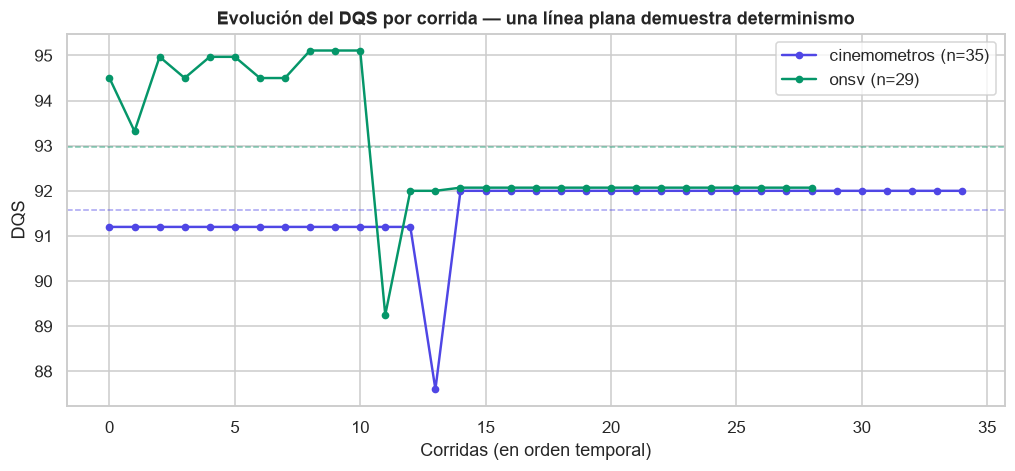

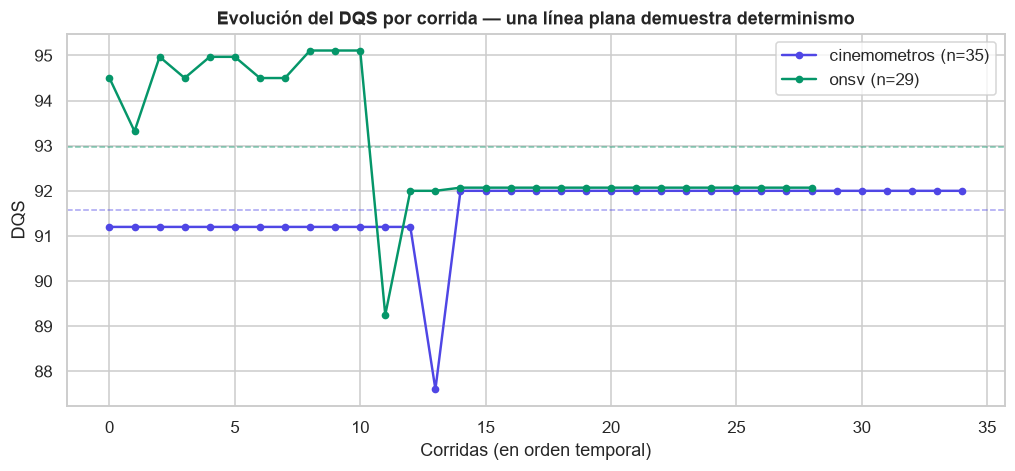

In [13]:
for ds, res in assess.items():
    serie = res['detalle']['drift'].get('serie', [])
    if serie:
        _show(F.plot_dqs_evolution(serie, F.figures_dir(), ds))

## 4.10 · El DQS que se está auditando

Contexto de fondo: el número 92.07 es una media ponderada de estas dimensiones,
y la frescura es baja **porque la fuente es histórica**, no por un defecto del
proceso. Un dato de 2021 no es «fresco» en 2026, y eso es lo correcto.

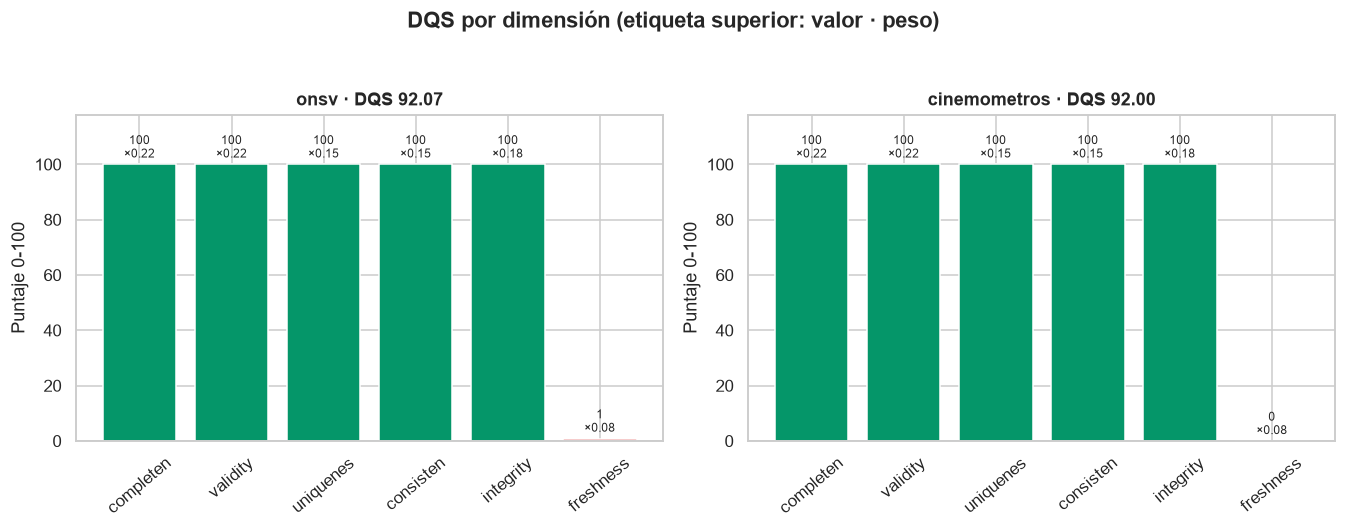

In [14]:
_show(F.plot_dqs_dimensions({ds: res['dqs'] for ds, res in assess.items()},
                           F.figures_dir()))

## 4.11 · Los veredictos, de un vistazo

Una fila por afirmación. El gris (`no_verificable`) no es un fallo del sistema: es
el punto donde los datos disponibles dejan de poder responder la pregunta.

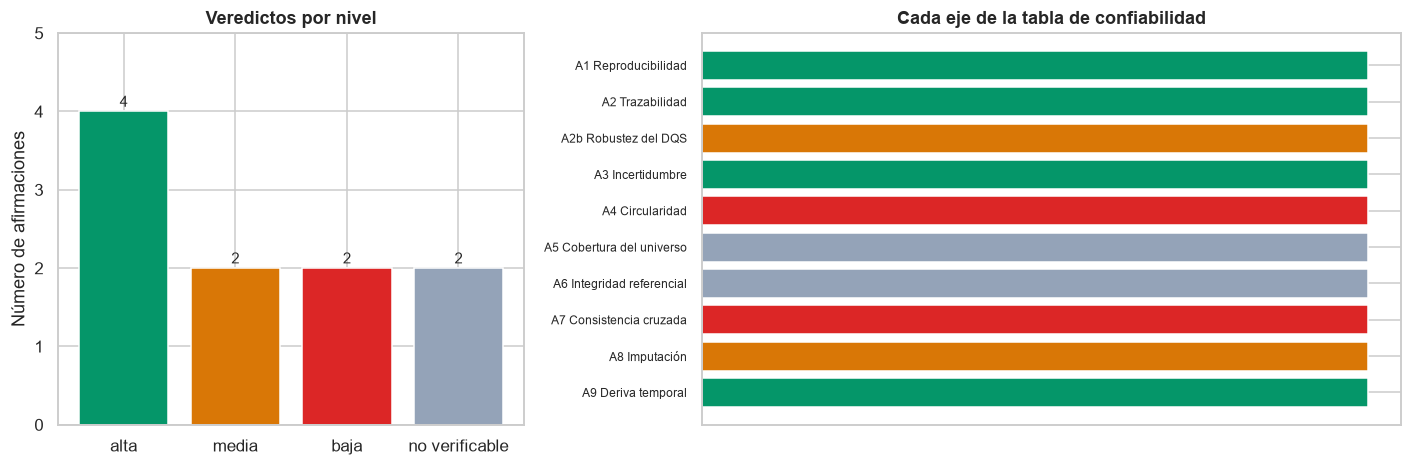

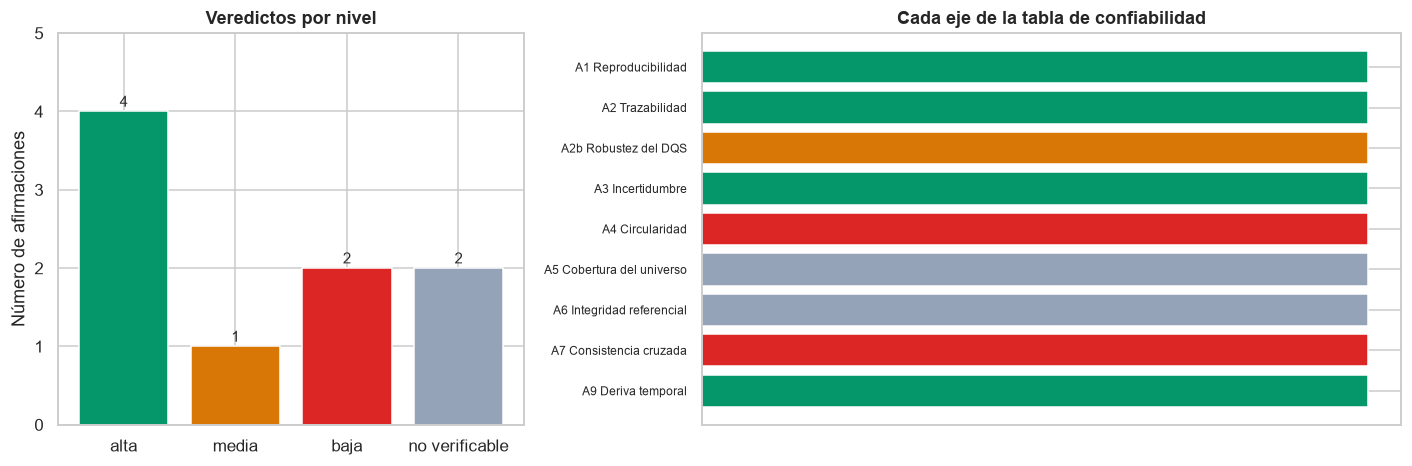

In [15]:
for ds, res in assess.items():
    _show(F.plot_reliability_claims(res['claims'], F.figures_dir(), ds))

In [16]:
_matriz = pd.DataFrame({ds: {c['axis']: c['verdict'] for c in res['claims']}
                     for ds, res in assess.items()})
display(_matriz)
print('\nConteos por veredicto (NO es un índice de confiabilidad):')
display(pd.DataFrame({ds: res['resumen_veredictos']
                      for ds, res in assess.items()}).fillna(0).astype(int))

,onsv,cinemometros
Reproducibilidad,alta,alta
Trazabilidad,alta,alta
Robustez del DQS,media,media
Incertidumbre,alta,alta
Circularidad,baja,baja
Cobertura del universo,no_verificable,no_verificable
Integridad referencial,no_verificable,no_verificable
Consistencia cruzada,baja,baja
Imputación,media,NaN
Deriva temporal,alta,alta



Conteos por veredicto (NO es un índice de confiabilidad):


,onsv,cinemometros
alta,4,4
media,2,1
baja,2,2
no_verificable,2,2


## 4.12 · Errores a no heredar

Defectos reales encontrados al implementar este apartado, cada uno con su
test de regresión en `tests/unit/test_regressions.py`. El primero es el más
interesante desde el punto de vista estadístico.

### 1. El bootstrap sesgado por duplicar las claves primarias

Remuestrear filas **con reemplazo** duplica las claves primarias, así que la
dimensión *unicidad* se desploma por un artefacto del remuestreo. El primer
resultado fue **punto 92.07 contra IC [86.45, 86.65]**: un intervalo que no
contiene a su propio estimador puntual, que es la señal clásica de un bootstrap
sesgado. Publicar esa «incertidumbre» habría sido un error metodológico.

Arreglo: `bootstrap.fix_dimensions: [uniqueness, integrity]` en la config — las
dimensiones invariantes al muestreo se fijan al valor observado.

### 2. Elegir la huella de medición equivocada

La «huella vigente» se elegía como la **más frecuente**, que en ese momento eran
corridas antiguas con la medición ya corregida. El veredicto de reproducibilidad
salía `baja` por un motivo inexistente. Ahora se elige la huella del código
actual.

### 3. El auditor dentro de la huella que lo audita

Un glob `src/quality/*.py` incluía `reliability.py` en la huella. Consecuencia:
tocar el auditor invalidaba la comparabilidad de las corridas, que es
exactamente lo que la huella debe evitar.

### 4. `Agg` en el notebook

`matplotlib.use('Agg')` está bien en un script, pero en un notebook **anula el
render inline**: las celdas se ejecutan «sin error» y no muestran ninguna figura.
Es el motivo de que este notebook incruste los PNG en base64 en vez de llamar a
`plt.show()`.

### 5. Figuras sobrescritas entre datasets

Las figuras comunes usaban el mismo nombre para ONSV y para cinemómetros, así
que una pisaba a la otra. Ahora cada nombre lleva su dataset.

### 6. Evidencia de reproducibilidad que se contradecía a sí misma

El `min`/`max` de DQS que accompanyaba a la afirmación de reproducibilidad se
calculaba sobre **todas** las huellas de medición, al lado del rango de la
vigente. La fila publicado decía `dqs_min=89.25, dqs_max=95.11,
rango=0.00` con veredicto `alta`: se leía como una inestabilidad de casi seis
puntos en un pipeline que es perfectamente determinista.

Arreglo: `run_drift` expone ahora `dqs_min_huella_vigente` /
`dqs_max_huella_vigente`, y la afirmación A1 usa esos. Los extremos globales
siguen disponibles, con nombre explícito, para poder revisar los cambios de
método.

## 4.13 · Conclusiones

Lo que **sí** se puede sostener:

1. El pipeline es **determinista**: misma huella de medición, mismo DQS. No es
   determinismo declarado, es medido.
2. Cada número es **trazable** hasta el fichero original, con checksum de fuente
   y Bronze inmutable.
3. El DQS es un **estimador muy preciso**: el IC es de décimas de punto.
4. La limpieza **funciona y se ve** en la figura de nulos antes/después.

Lo que **no** se puede sostener:

1. La validación por catálogos es **circular**: es consistencia interna, no
   validación externa.
2. El DQS depende de los **pesos** que elegí: va del 70 al 100 según el escenario.
3. La **cobertura del universo** es la incógnita más grande y sigue sin verificar.

### Cómo decirlo en una sustentación

> No: «nuestro pipeline tiene 92 % de confiabilidad». Ese número no existe.

> Sí: «El DQS de nuestro dataset es 92.07 con un intervalo de confianza de
> décimas de punto: es un estimador estable, determinista y trazable. Somos
> conscientes de tres límites: la validación de catálogos es circular porque los
> derivamos del propio dato, el score depende de los pesos que elegimos, y no
> podemos verificar la cobertura del universo sin el total oficial de la ONSV».

### Reproducibilidad

Todo lo de este notebook se regenera con:

```bash
python scripts/run_pipeline.py      # Silver real
python scripts/graficos_etl.py      # recalcula la tabla y dibuja
```

Los umbrales están en `config/quality/reliability_rules.yaml`; el motor es
`src/quality/reliability.py`; el informe autocontenido se genera en
`reports/reliability/<dataset>_confiabilidad_*.html`.